📂 Directory 'reports1/figures' created.
✅ Dataset Loaded Successfully!
       longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0        -122.23     37.88                  41          880           129.0   
1        -122.22     37.86                  21         7099          1106.0   
2        -122.24     37.85                  52         1467           190.0   
3        -122.25     37.85                  52         1274           235.0   
4        -122.25     37.85                  52         1627           280.0   
...          ...       ...                 ...          ...             ...   
20635    -121.09     39.48                  25         1665           374.0   
20636    -121.21     39.49                  18          697           150.0   
20637    -121.22     39.43                  17         2254           485.0   
20638    -121.32     39.43                  18         1860           409.0   
20639    -121.24     39.37                  16         2785 

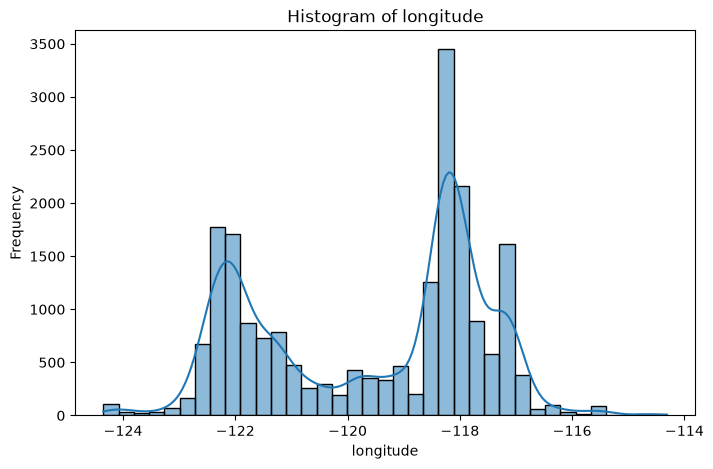

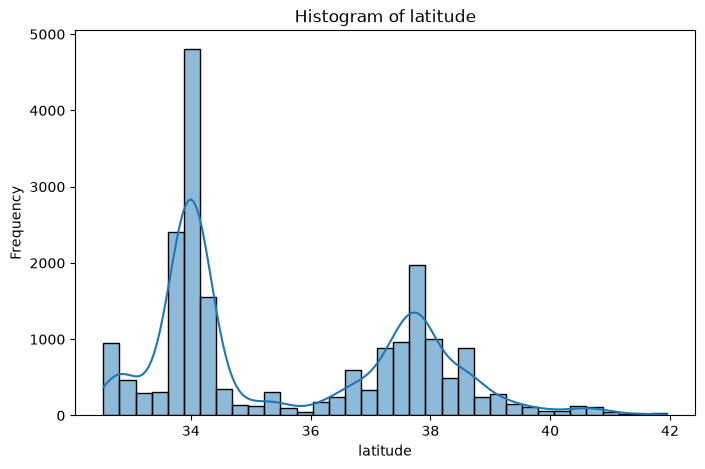

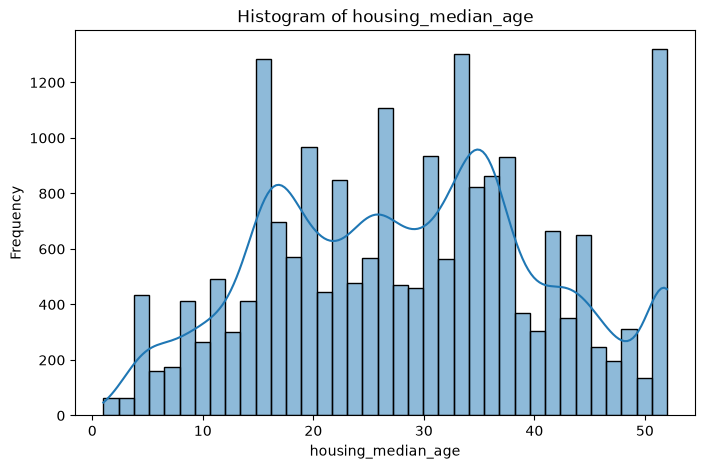

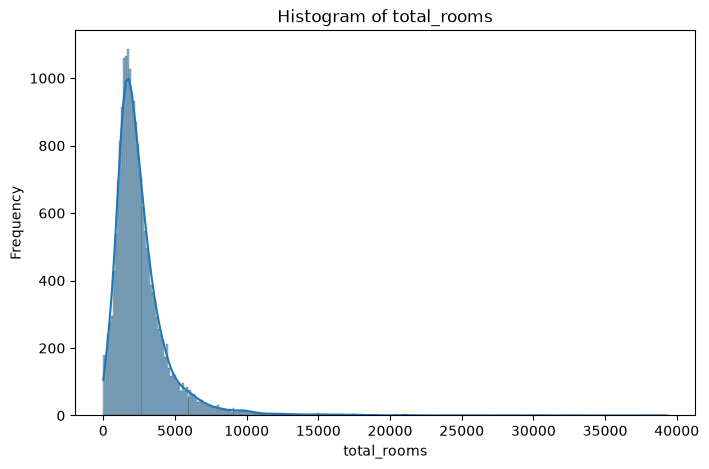

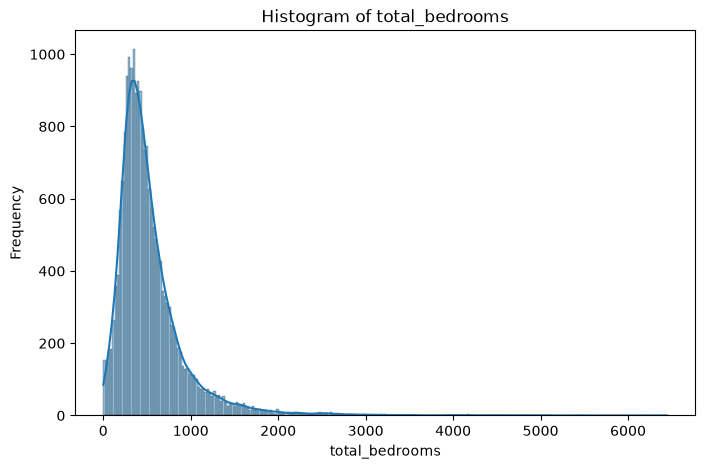

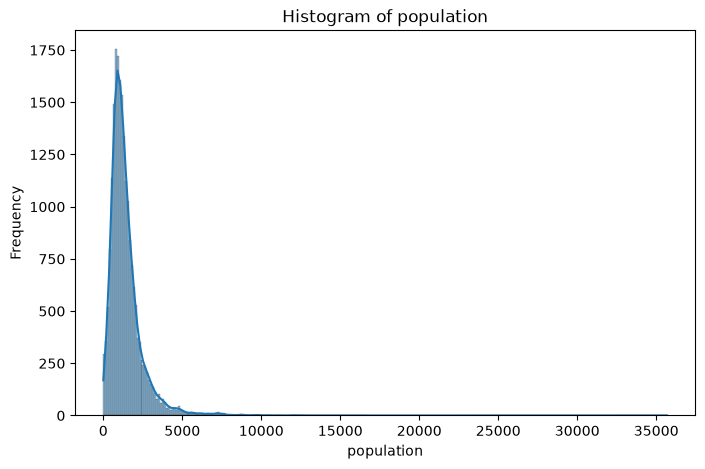

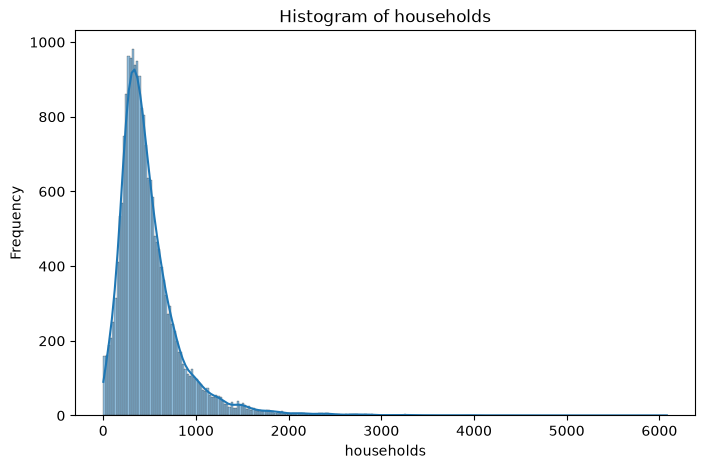

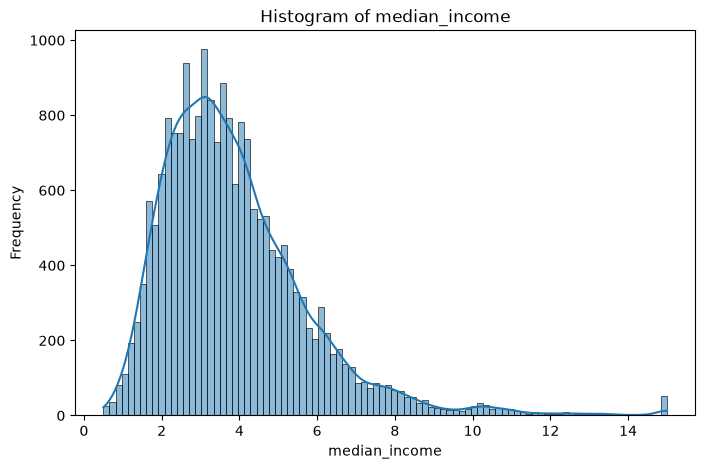

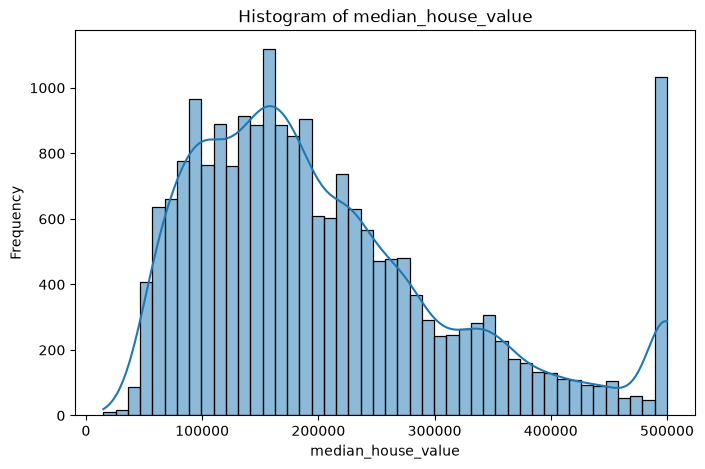

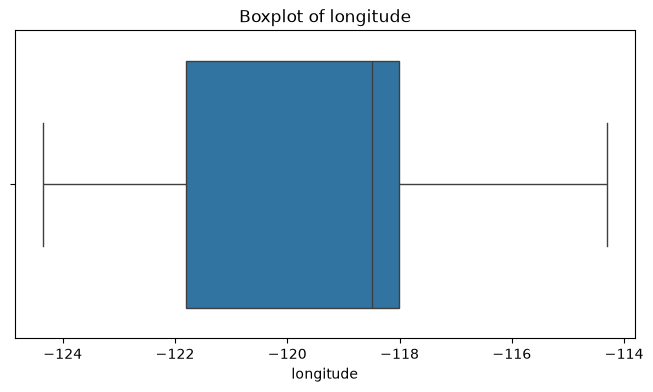

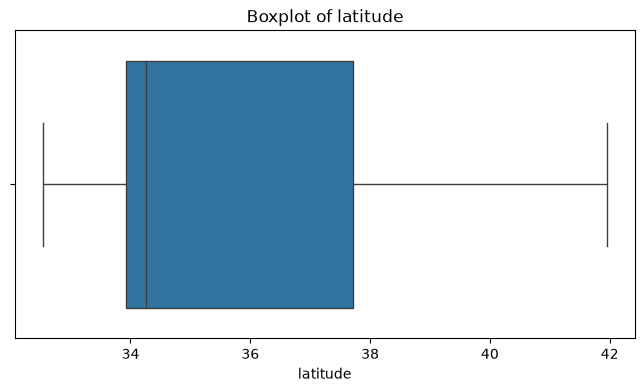

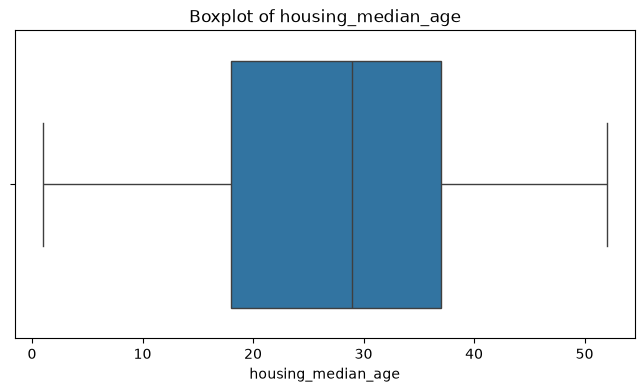

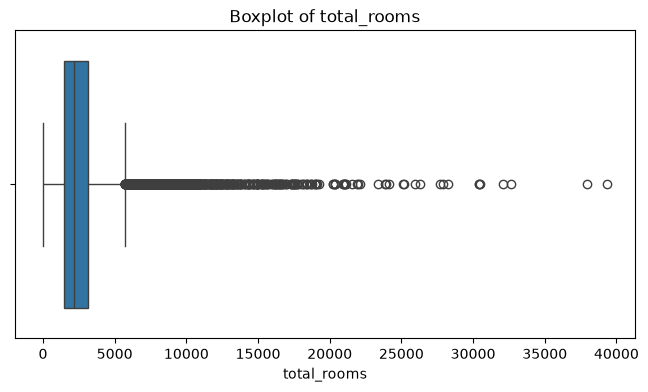

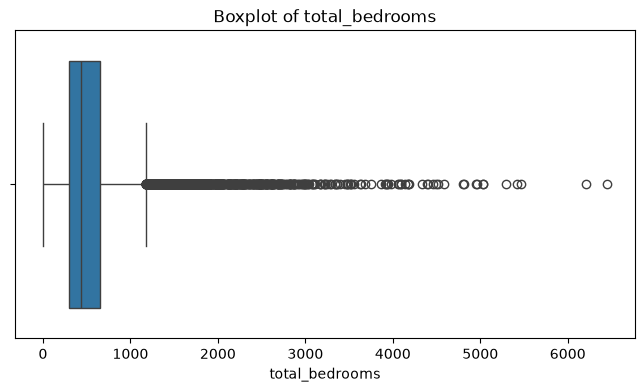

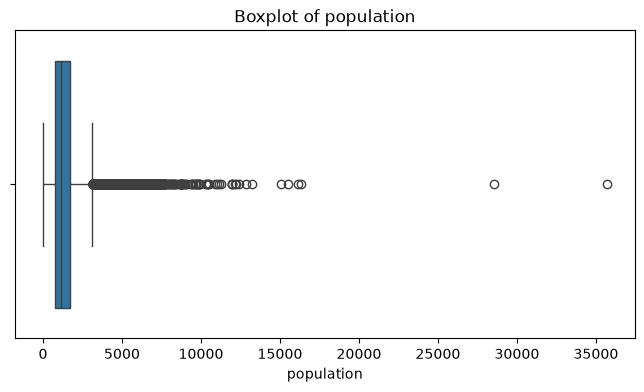

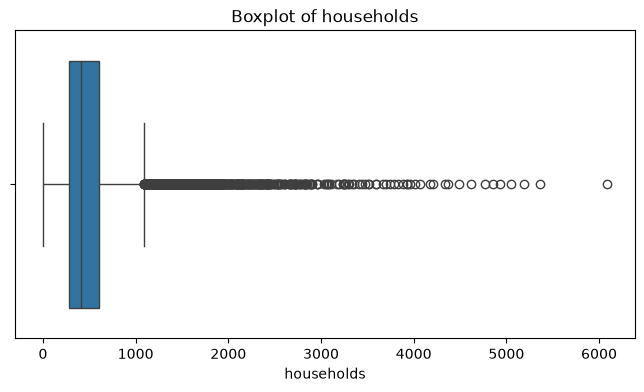

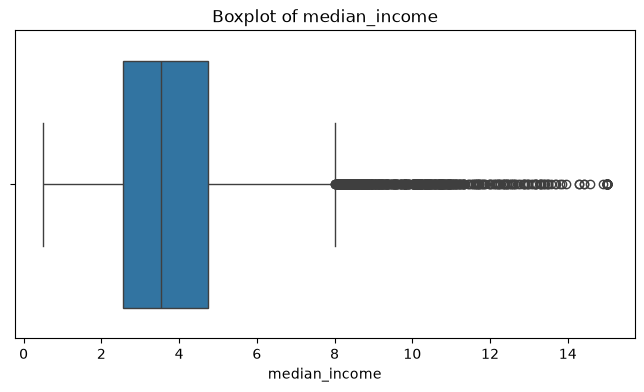

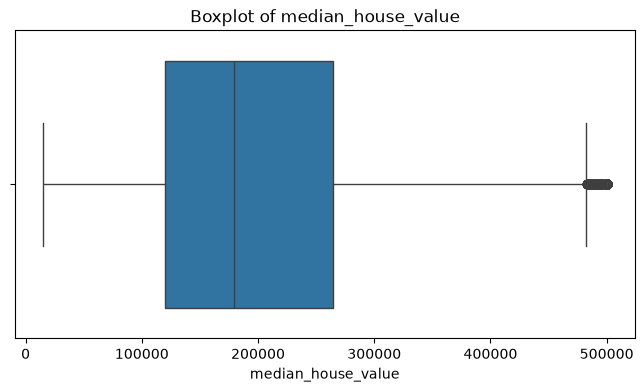

longitude : 0 outliers
latitude : 0 outliers
housing_median_age : 0 outliers
total_rooms : 1287 outliers
total_bedrooms : 1271 outliers
population : 1196 outliers
households : 1220 outliers
median_income : 681 outliers
median_house_value : 1071 outliers

✅ All graphs saved in 'reports1/figures' folder.


In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Create folder to store generated images
os.makedirs("reports1/figures", exist_ok=True)

print("📂 Directory 'reports1/figures' created.")

# Load dataset
df = pd.read_csv("housing.csv")

print("✅ Dataset Loaded Successfully!")
print(df)
print(df.head())
print(df.shape)
print(df.columns)

# ------------------------------------------------
# 1. Generate and Save Histograms
# ------------------------------------------------

for col in df.select_dtypes("number"):

    plt.figure(figsize=(8, 5))
    sns.histplot(df[col], kde=True)

    plt.title("Histogram of " + col)
    plt.xlabel(col)
    plt.ylabel("Frequency")

    # Save image
    plt.savefig(
        "reports1/figures/histogram_" + col + ".png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()
    plt.close()

# ------------------------------------------------
# 2. Generate and Save Boxplots
# ------------------------------------------------

for col in df.select_dtypes("number"):

    plt.figure(figsize=(8, 4))
    sns.boxplot(x=df[col])

    plt.title("Boxplot of " + col)
    plt.xlabel(col)

    # Save image
    plt.savefig(
        "reports1/figures/boxplot_" + col + ".png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()
    plt.close()

# ------------------------------------------------
# 3. Detect Outliers using IQR
# ------------------------------------------------

for col in df.select_dtypes("number"):

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    outliers = df[
        (df[col] < Q1 - 1.5 * IQR) |
        (df[col] > Q3 + 1.5 * IQR)
    ]

    print(col, ":", len(outliers), "outliers")

print("\n✅ All graphs saved in 'reports1/figures' folder.")